# Стекинг и многослойный персептрон

Лабораторная работа №7.

**Задача:** многоклассовая классификация — предсказать вид пингвина (`species`).

**Датасет:** `seaborn.load_dataset('penguins')` — числовые и категориальные признаки, есть пропуски.

## 1) Описание набора данных

- Документация Seaborn: https://seaborn.pydata.org/generated/seaborn.load_dataset.html
- Исходное описание: https://allisonhorst.github.io/palmerpenguins/

Набор содержит **344** записи (после удаления строк с пропусками в целевой переменной). Целевая переменная — `species` (Adelie, Chinstrap, Gentoo).

| Тип | Признаки |
|-----|----------|
| Числовые | `bill_length_mm`, `bill_depth_mm`, `flipper_length_mm`, `body_mass_g` |
| Категориальные | `island`, `sex` |

В данных есть **пропуски** (в числовых признаках и в `sex`), что позволяет показать этап предобработки.
Датасет подходит для сравнения стекинга и нейросетевого классификатора на табличных признаках.

## Импорт библиотек

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import (
    StackingClassifier,
    RandomForestClassifier,
    GradientBoostingClassifier,
)
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
)

%matplotlib inline
sns.set(style="ticks")

## Загрузка и первичный осмотр

In [2]:
df = sns.load_dataset('penguins')
print(f'Размер: {df.shape}')
df.head()

Размер: (344, 7)


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


In [3]:
print('Пропуски по столбцам:')
print(df.isna().sum())
print()
print('Распределение целевой переменной:')
print(df['species'].value_counts(normalize=True).round(3))

Пропуски по столбцам:
species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
dtype: int64

Распределение целевой переменной:
species
Adelie       0.442
Gentoo       0.360
Chinstrap    0.198
Name: proportion, dtype: float64


## Предобработка данных

Используем морфометрические признаки и категории `island`, `sex`.
Числовые пропуски заполняем медианой, категориальные — модой. Категориальные признаки кодируем one-hot.
Строки без целевой переменной удаляем.

In [4]:
df = df.dropna(subset=['species']).copy()

FEATURES = [
    'island', 'bill_length_mm', 'bill_depth_mm',
    'flipper_length_mm', 'body_mass_g', 'sex',
]
TARGET = 'species'

X = df[FEATURES].copy()
y_raw = df[TARGET]

label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y_raw)
class_names = label_encoder.classes_

numeric_features = [
    'bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g',
]
categorical_features = ['island', 'sex']

numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
])

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore')),
])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features),
])

## Разделение на обучающую и тестовую выборки

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42,
    stratify=y,
)

print(f'Обучающая выборка: {X_train.shape[0]} объектов')
print(f'Тестовая выборка:   {X_test.shape[0]} объектов')

Обучающая выборка: 258 объектов
Тестовая выборка:   86 объектов


## Обучение моделей

1. **Stacking** — стекинг: базовые модели (k-NN, случайный лес, градиентный бустинг), мета-классификатор — логистическая регрессия.
2. **MLP** — многослойный персептрон (`sklearn.neural_network.MLPClassifier`).

Документация по нейросетям в scikit-learn: https://scikit-learn.org/stable/modules/neural_networks_supervised.html

In [6]:
RANDOM_STATE = 42

base_estimators = [
    ('knn', KNeighborsClassifier(n_neighbors=5)),
    ('rf', RandomForestClassifier(n_estimators=100, max_depth=6, random_state=RANDOM_STATE)),
    ('gb', GradientBoostingClassifier(n_estimators=100, max_depth=3, random_state=RANDOM_STATE)),
]

models = {
    'Stacking': Pipeline([
        ('prep', preprocessor),
        ('model', StackingClassifier(
            estimators=base_estimators,
            final_estimator=LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
            cv=5,
            passthrough=False,
        )),
    ]),
    'MLP': Pipeline([
        ('prep', preprocessor),
        ('model', MLPClassifier(
            hidden_layer_sizes=(64, 32),
            activation='relu',
            solver='adam',
            max_iter=500,
            random_state=RANDOM_STATE,
            early_stopping=True,
            validation_fraction=0.15,
        )),
    ]),
}

In [7]:
results = []
predictions = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    predictions[name] = y_pred

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='macro')
    results.append({'Модель': name, 'Accuracy': acc, 'F1-score (macro)': f1})

    print(f'=== {name} ===')
    print(classification_report(y_test, y_pred, target_names=class_names))
    print()

=== Stacking ===
              precision    recall  f1-score   support

      Adelie       1.00      1.00      1.00        38
   Chinstrap       1.00      1.00      1.00        17
      Gentoo       1.00      1.00      1.00        31

    accuracy                           1.00        86
   macro avg       1.00      1.00      1.00        86
weighted avg       1.00      1.00      1.00        86


=== MLP ===
              precision    recall  f1-score   support

      Adelie       0.72      1.00      0.84        38
   Chinstrap       1.00      0.12      0.21        17
      Gentoo       1.00      1.00      1.00        31

    accuracy                           0.83        86
   macro avg       0.91      0.71      0.68        86
weighted avg       0.87      0.83      0.77        86




## Сравнение качества моделей

Для задачи многоклассовой классификации используем **Accuracy** и **F1-score (macro)** — усреднение F1 по классам с равными весами.

In [8]:
results_df = pd.DataFrame(results).sort_values('F1-score (macro)', ascending=False).reset_index(drop=True)
results_df

,Модель,Accuracy,F1-score (macro)
0,Stacking,1.000000,1.000000
1,MLP,0.825581,0.681897


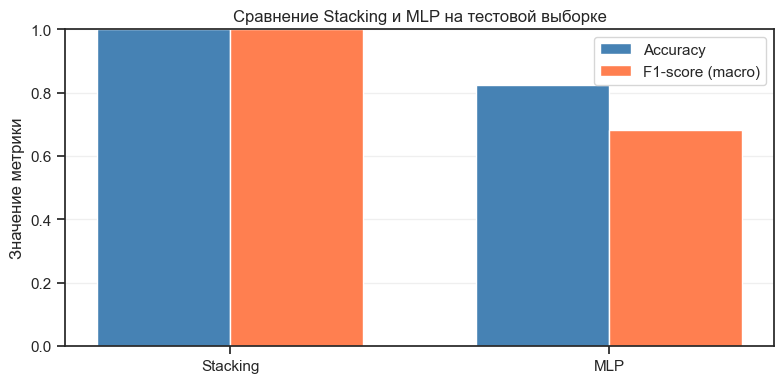

In [9]:
fig, ax = plt.subplots(figsize=(8, 4))

x = np.arange(len(results_df))
width = 0.35

ax.bar(x - width / 2, results_df['Accuracy'], width, label='Accuracy', color='steelblue')
ax.bar(x + width / 2, results_df['F1-score (macro)'], width, label='F1-score (macro)', color='coral')

ax.set_xticks(x)
ax.set_xticklabels(results_df['Модель'])
ax.set_ylim(0, 1)
ax.set_ylabel('Значение метрики')
ax.set_title('Сравнение Stacking и MLP на тестовой выборке')
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## Выводы

1. Данные предобработаны: удалены строки без целевой переменной, заполнены пропуски, категориальные признаки закодированы one-hot, числовые — масштабированы.
2. **Stacking** объединяет предсказания нескольких базовых моделей через мета-классификатор, что часто повышает устойчивость по сравнению с отдельными алгоритмами.
3. **MLP** — полносвязная нейросеть; на небольших табличных данных может сопоставимо или лучше/хуже стекинга в зависимости от гиперпараметров.
4. Сравнение по метрикам на тестовой выборке приведено в таблице и на графике выше.